In [151]:
import numpy as np


In [152]:

actual_rate_1 = 20
actual_rate_2 = 10
actual_lambda1 = 1/actual_rate_1
actual_lambda2 = 1/actual_rate_2
samples_len_1 = 9_000
samples_len_2 = 3_000
actual_p = samples_len_1 / (samples_len_1 + samples_len_2)

samples_1 = np.random.exponential(scale=actual_rate_1, size=samples_len_1)
samples_2 = np.random.exponential(scale=actual_rate_2, size=samples_len_2)
print(f'The mean of samples_1={round(samples_1.mean(),2)}, and sample_2={round(samples_2.mean(), 2)}')
samples = np.concatenate((samples_1 , samples_2 )) # list(samples_1) + list(samples_2)
np.random.shuffle(samples)

The mean of samples_1=19.96, and sample_2=9.91


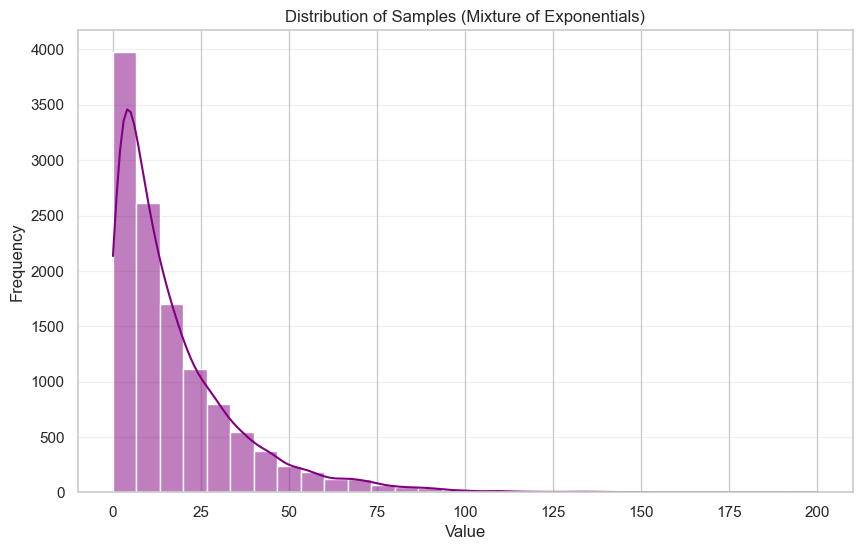

In [153]:
len(samples) , samples[:10]
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
sns.histplot(samples, kde=True, color='purple', bins=30)

# Add styling
plt.title('Distribution of Samples (Mixture of Exponentials)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [154]:
rate_1 = 40
rate_2 = 1
lambda_1 = 1/ rate_1
lambda_2 = 1/ rate_2
p = 0.5
trends = [dict(rate_1=1, rate_2=rate_2,
               lambda_1=lambda_1, lambda_2=lambda_2, p=p)]
for i in range(1_200):
    data = []
    for sample in samples:
        effect_1 = p * lambda_1 * np.exp(- lambda_1 * sample)
        effect_2 = (1 - p) * lambda_2 * np.exp(- lambda_2 * sample)
        responsibility_1 = effect_1 / (effect_1 + effect_2)
        responsibility_2 = 1 - responsibility_1
        
        time_t1 = responsibility_1 * sample
        time_t2 = responsibility_2 * sample

        row = dict(responsibility_1=responsibility_1, responsibility_2=responsibility_2,
                   time_t1=time_t1, time_t2=time_t2,)
        data.append(row)

    t1_values = np.array([row['time_t1'] for row in data])
    t2_values = np.array([row['time_t2'] for row in data])
    responsibilities_1 = np.array([row['responsibility_1'] for row in data])
    responsibilities_2 = np.array([row['responsibility_2'] for row in data])
    rate_1 = t1_values.sum() / responsibilities_1.sum() 
    rate_2 = t2_values.sum() / responsibilities_2.sum()
    lambda_1 = 1 / rate_1 # t1_values.sum() / responsibilities_1.sum()
    lambda_2 = 1 / rate_2 # t2_values.sum() / responsibilities_2.sum()
    p = responsibilities_1.mean()
    trends.append(dict(rate_1=rate_1, rate_2=rate_2,
                       lambda_1=lambda_1, lambda_2=lambda_2, p=p))
    

In [155]:
trends[:5]

[{'rate_1': 1, 'rate_2': 1, 'lambda_1': 0.025, 'lambda_2': 1.0, 'p': 0.5},
 {'rate_1': 21.314023216852448,
  'rate_2': 2.1633710254534635,
  'lambda_1': 0.046917467895471084,
  'lambda_2': 0.4622415610796074,
  'p': 0.7981897892148678},
 {'rate_1': 20.067083693925188,
  'rate_2': 2.821843182378241,
  'lambda_1': 0.04983285141242149,
  'lambda_2': 0.35437830360126643,
  'p': 0.8481982532665245},
 {'rate_1': 19.57539279736111,
  'rate_2': 3.315328554213796,
  'lambda_1': 0.05108454325038149,
  'lambda_2': 0.3016292303002657,
  'p': 0.8692399547668641},
 {'rate_1': 19.306595401593952,
  'rate_2': 3.713612223658079,
  'lambda_1': 0.05179577129986575,
  'lambda_2': 0.2692795961919131,
  'p': 0.8808842850039964}]

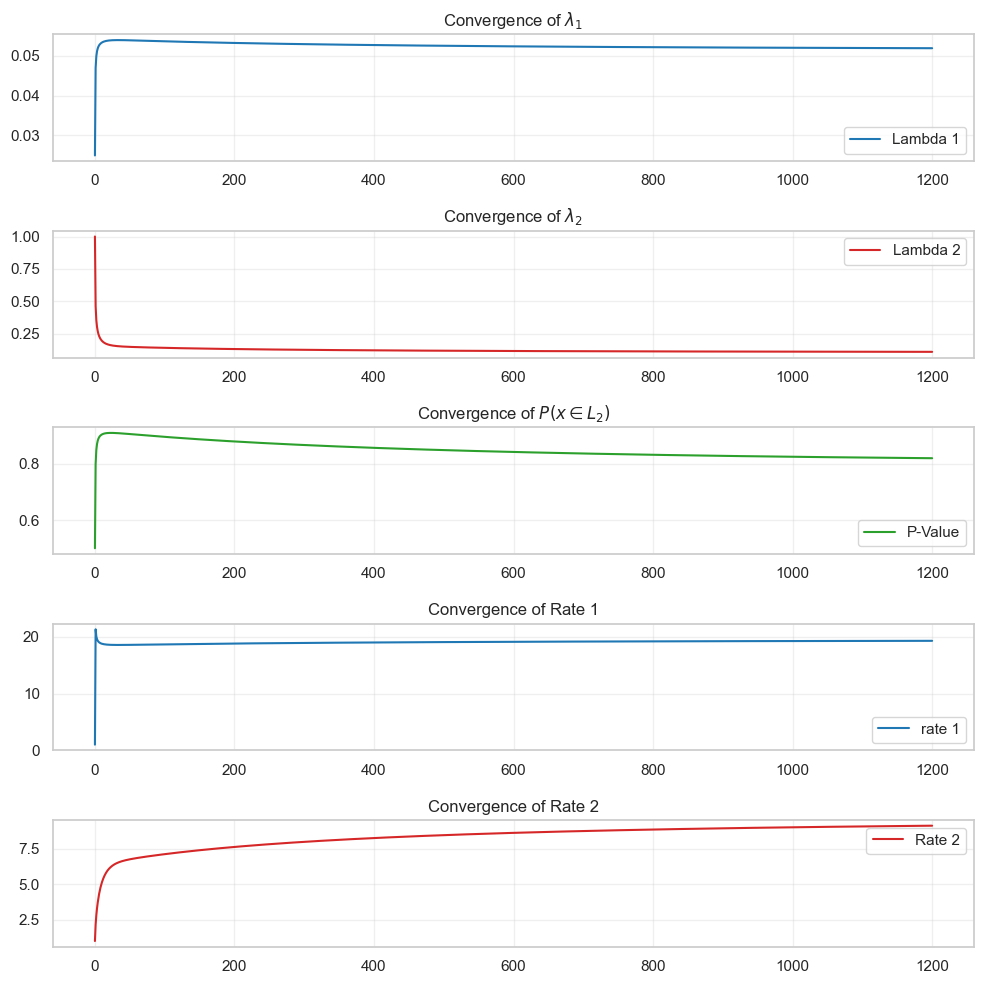

In [156]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(trends)

fig, axes = plt.subplots(5, 1, figsize=(10, 10))

# Customizing each subplot
axes[0].plot(df['lambda_1'], color='tab:blue', label='Lambda 1')
axes[0].set_title('Convergence of $\lambda_1$')

axes[1].plot(df['lambda_2'], color='tab:red', label='Lambda 2')
axes[1].set_title('Convergence of $\lambda_2$')

axes[2].plot(df['p'], color='tab:green', label='P-Value')
axes[2].set_title('Convergence of $P(x \in L_2)$')

# Customizing each subplot
axes[3].plot(df['rate_1'], color='tab:blue', label='rate 1')
axes[3].set_title('Convergence of Rate 1')

axes[4].plot(df['rate_2'], color='tab:red', label='Rate 2')
axes[4].set_title('Convergence of Rate 2')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

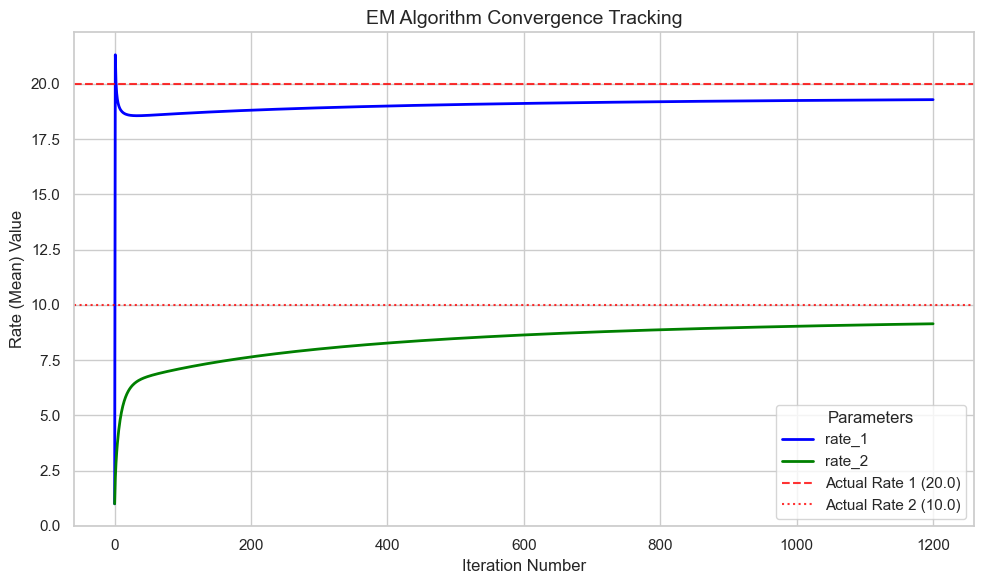

In [157]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
df_trends = pd.DataFrame(trends)
df_trends['iteration'] = df_trends.index

# Melt for Seaborn "hue" mapping
df_melted = df_trends.melt(id_vars=['iteration'], 
                           value_vars=['rate_1', 'rate_2'], 
                           var_name='Parameter', 
                           value_name='Estimate')

# 2. Setup the Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Draw the estimate lines (Blue for rate_1, Green for rate_2)
sns.lineplot(data=df_melted, 
             x='iteration', 
             y='Estimate', 
             hue='Parameter', 
             palette={'rate_1': 'blue', 'rate_2': 'green'},
             linewidth=2)

# 4. Add the two RED horizontal lines for actual rates
plt.axhline(y=1/actual_lambda1, color='red', linestyle='--', alpha=0.8, 
            label=f'Actual Rate 1 ({round(1/actual_lambda1, 2)})')

plt.axhline(y=1/actual_lambda2, color='red', linestyle=':', alpha=0.8, 
            label=f'Actual Rate 2 ({round(1/actual_lambda2, 2)})')

# 5. Formatting
plt.title('EM Algorithm Convergence Tracking', fontsize=14)
plt.xlabel('Iteration Number')
plt.ylabel('Rate (Mean) Value')
plt.legend(title='Parameters', loc='best')

plt.tight_layout()
plt.show()